In [1]:
import pandas as pd
import sqlite3

In [2]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

## download data from pageviews

In [3]:
pageviews = pd.read_sql(
    '''
SELECT datetime
FROM pageviews
WHERE uid LIKE 'user_%'
''', conn, parse_dates='datetime'
)

In [4]:
pageviews_grouped = pageviews.groupby(pageviews['datetime'].dt.date).count()

In [5]:
pageviews_grouped

,datetime
datetime,
2020-04-17,1
2020-04-18,23
2020-04-19,15
2020-04-21,3
2020-04-22,1
2020-04-23,5
2020-04-25,1
2020-04-26,8
2020-04-28,2


## download data from checkers

In [6]:
checking = pd.read_sql(
    '''
SELECT timestamp
FROM checker
WHERE uid LIKE 'user_%' ''', conn, parse_dates='timestamp'
)

In [7]:
checking_grouped = checking.groupby(checking.timestamp.dt.date).count()
checking_grouped.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35 entries, 2020-04-17 to 2020-05-21
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   timestamp  35 non-null     int64
dtypes: int64(1)
memory usage: 560.0+ bytes


## get dataframe with both date

In [8]:
pageviews_and_commits = pageviews_grouped.join(checking_grouped, how='inner')
pageviews_and_commits = pageviews_and_commits.rename(columns={'datetime' :  'views', 'timestamp' : 'commits'})
pageviews_and_commits.count()

views      32
commits    32
dtype: int64

## draw a graph

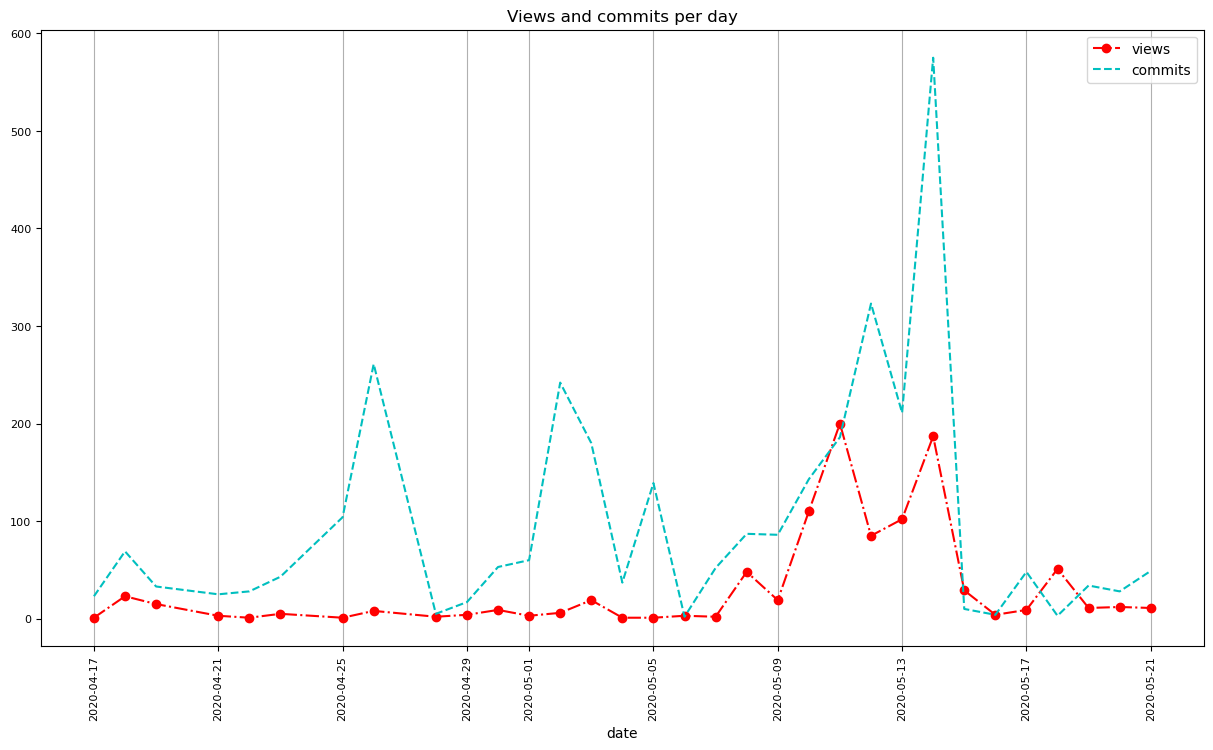

In [9]:
graph = pageviews_and_commits.plot(
    fontsize=8,
    figsize=(15,8),
    rot=90, 
    title='Views and commits per day', 
    xlabel='date',
    style={
        'views' : 'r-.o',
        'commits' : 'c--'
    }
    )
graph.grid(axis='x')



In [10]:
pageviews_and_commits.views[pageviews_and_commits.views > 150].count()

2

### How many times was the number of views lagrer than 150 ?
### The answer is 2.

In [11]:
conn.close()